In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', None)


In [2]:
df_raw = pd.read_csv("D:/2022-2026/Project-Data Analysis/DA_Channel/data/raw/retail_sales_dataset.csv")
df = df_raw.copy()

In [3]:
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2025-09-05,C000820,Other,35-44,Vip,P1082,Dumbbells,Sports,Brand 1,2,313.53,20.0,501.65,Debit Card,Online,North
1,T0000002,2025-11-21,C002849,Other,45-54,Returning,P1087,Running Shoes,Sports,Brand 3,1,366.16,0.0,366.16,Credit Card,Online,South
2,T0000003,2024-10-24,C019727,Male,55+,New,P1030,Sneakers,Clothing,Brand 3,1,27.99,0.0,27.99,Gift Card,In-Store,South
3,T0000004,2025-10-13,C009116,Male,25-34,Loyal,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15.0,173.42,Cash,In-Store,South
4,T0000005,2025-11-18,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0.0,259.55,Cash,Mobile App,Central


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     119844 non-null  object 
 4   customer_age_group  119846 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        119810 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  float64
 13  sales_amount        119818 non-null  float64
 14  payment_method      119840 non-null  object 
 15  sales_channel       120000 non-nul

In [5]:
df.describe()

,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,119818.000000
mean,1.662625,240.611484,5.507762,378.814476
std,1.014755,146.460499,8.290149,391.034255
min,-5.000000,0.000000,0.000000,-531.100000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,192.620148,41520.000000


### Chuẩn hóa text

In [6]:
df['transaction_date'].head()

0    2025-09-05
1    2025-11-21
2    2024-10-24
3    2025-10-13
4    2025-11-18
Name: transaction_date, dtype: object

In [7]:
# df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [8]:
# xem phạm vi dữ liệu
min_date = df['transaction_date'].min()
max_date = df['transaction_date'].max()

print (min_date) 
print (max_date)

01/08/2025
30/11/2025


In [9]:
print(
    df["transaction_date"].astype(str).apply(
        lambda x: "YYYY-MM-DD" if x.count("-")==2
        else "DD/MM/YYYY" if x.count("/")==2
        else "Khác"
    ).value_counts()
)

transaction_date
YYYY-MM-DD    119950
DD/MM/YYYY        50
Name: count, dtype: int64


- Phát hiện định dạng thời gian giao dịch khác nhau

In [10]:
# thử parse theo 2 format bạn đang có
parsed = df["transaction_date"].apply(
    lambda x: pd.to_datetime(x, format="%Y-%m-%d", errors="coerce")
    if "-" in str(x)
    else pd.to_datetime(x, format="%d/%m/%Y", errors="coerce")
)

# lấy các dòng lỗi
errors = df[parsed.isna()]

print(errors["transaction_date"].unique())
print("Số dòng lỗi:", len(errors))

[]
Số dòng lỗi: 0


In [11]:
df["transaction_date"] = df["transaction_date"].apply(
    lambda x: pd.to_datetime(x, format="%Y-%m-%d", errors="coerce")
    if "-" in str(x)
    else pd.to_datetime(x, format="%d/%m/%Y", errors="coerce")
).dt.strftime("%Y-%m-%d")

print(df["transaction_date"].head())

0    2025-09-05
1    2025-11-21
2    2024-10-24
3    2025-10-13
4    2025-11-18
Name: transaction_date, dtype: object


In [12]:
# object -> bỏ khoảng trắng, viết hoa chữ cái đầu.
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()


In [13]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- transaction_id ---
['T0000001' 'T0000002' 'T0000003' ... 'T0119998' 'T0119999' 'T0120000']

--- transaction_date ---
['2025-09-05' '2025-11-21' '2024-10-24' '2025-10-13' '2025-11-18'
 '2025-05-27' '2024-03-17' '2024-10-01' '2024-09-13' '2024-07-27'
 '2025-09-02' '2024-12-11' '2025-04-03' '2025-06-25' '2025-01-18'
 '2025-07-17' '2024-06-21' '2024-07-22' '2024-03-20' '2024-11-28'
 '2025-09-28' '2025-02-10' '2024-05-28' '2025-11-29' '2025-06-11'
 '2025-05-05' '2025-06-27' '2024-12-25' '2025-09-14' '2025-08-24'
 '2024-04-14' '2025-12-17' '2024-12-19' '2024-01-20' '2024-11-04'
 '2025-10-22' '2024-12-01' '2025-01-23' '2025-03-07' '2024-10-30'
 '2024-07-02' '2025-10-24' '2025-05-04' '2025-07-08' '2024-06-25'
 '2025-12-28' '2025-10-16' '2025-12-03' '2025-05-06' '2024-05-03'
 '2024-11-10' '2025-07-18' '2025-04-19' '2024-01-02' '2024-08-09'
 '2024-12-26' '2025-04-26' '2024-07-08' '2025-09-15' '2024-07-28'
 '2025-04-24' '2024-05-17' '2024-05-16' '2025-05-02' '2025-08-23'
 '2025-11-24' '2025-

In [14]:
# Tính giá gốc (chưa giảm)
df["unit_price_original"] = df["sales_amount"] / df["quantity"]

# Nếu unit_price đã có discount thì nó phải bằng giá gốc * (1 - discount_pct)
df["unit_price_expected"] = df["unit_price_original"] * (1 - df["discount_pct"])

# So sánh unit_price với giá kỳ vọng sau discount
df["is_discount_applied"] = abs(df["unit_price"] - df["unit_price_expected"]) < 1e-6

# Kiểm tra kết quả
print(df[["unit_price", "unit_price_original", "discount_pct", "unit_price_expected", "is_discount_applied"]].head())


   unit_price  unit_price_original  discount_pct  unit_price_expected  \
0      313.53              250.825          20.0            -4765.675   
1      366.16              366.160           0.0              366.160   
2       27.99               27.990           0.0               27.990   
3      102.01               86.710          15.0            -1213.940   
4      259.55              259.550           0.0              259.550   

   is_discount_applied  
0                False  
1                 True  
2                 True  
3                False  
4                 True  


- Có 8 danh mục sản phẩm khác nhau
- 3 kênh bán hàng 

- Giá trị phân loại cột `peyment_method` không nhất quán ở `Gift Card` và `Giftcard`
- Các giá trị phân loại của các cột còn lại đều nhất quán.

In [15]:
df['payment_method'] = df['payment_method'].replace({'Giftcard': 'Gift Card'})

### Chuyển đổi kiểu dữ liệu 

In [16]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [17]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')


### Xử lý duplicate


In [18]:
dup = df.duplicated().sum()
print(dup)

0


In [19]:
print(df.duplicated('transaction_id', keep=False).sum())

0


In [20]:
logic_cols = [
    'transaction_id',
    'transaction_date',
    'customer_id',
    'product_id'
]

print(df.duplicated(logic_cols, keep=False).sum())


0


### Xử lý missing

In [21]:
missing = df.isna().sum()
print(missing)


transaction_id           0
transaction_date         0
customer_id              0
customer_gender        156
customer_age_group     154
customer_segment         0
product_id               0
product_name           190
category                 0
brand                    0
quantity                 0
unit_price               0
discount_pct             0
sales_amount           182
payment_method         160
sales_channel            0
region                 158
unit_price_original    182
unit_price_expected    182
is_discount_applied      0
dtype: int64


In [22]:
from scipy.stats import chi2_contingency

# các cột có missing
missing_cols = df.columns[df.isnull().sum() > 0]
results = []

for col in missing_cols:
    miss_flag = df[col].isnull().astype(int)
    related = []

    for other in df.columns:
        if other == col:
            continue
        try:
            # với biến category
            if df[other].dtype == 'category':
                table = pd.crosstab(df[other], miss_flag)
                if table.shape[1] == 2:
                    _, p, _, _ = chi2_contingency(table)
                    if p < 0.05:
                        related.append(other)
            # với biến số
            else:
                grouped = df.groupby(miss_flag)[other]
                if len(grouped) == 2:
                    mean_diff = abs(grouped.mean().diff().iloc[-1])
                    if mean_diff > df[other].std() * 0.1:
                        related.append(other)
        except:
            pass

    if len(related) == 0:
        missing_type = "MCAR"
    else:
        missing_type = f"MAR (related to: {', '.join(related[:10])})"

    results.append({
        "column": col,
        "missing_count": df[col].isnull().sum(),
        "classification": missing_type
    })

missing_report = pd.DataFrame(results)
missing_report

,column,missing_count,classification
0,customer_gender,156,MAR (related to: customer_id)
1,customer_age_group,154,"MAR (related to: customer_id, quantity, sales_amount)"
2,product_name,190,"MAR (related to: quantity, unit_price, sales_amount)"
3,sales_amount,182,MAR (related to: is_discount_applied)
4,payment_method,160,MCAR
5,region,158,MAR (related to: customer_id)
6,unit_price_original,182,MAR (related to: is_discount_applied)
7,unit_price_expected,182,MAR (related to: is_discount_applied)


- Missing customer_gender

In [23]:
# Kiểm tra missing của customer_gender có phụ thuộc biến nào không

print("Missing rate:")
print(df["customer_gender"].isnull().mean())

for col in ['customer_segment', 'category', 'payment_method']:
    print(f"\nMissing theo {col}")
    print(df.groupby(col)['customer_gender']
            .apply(lambda x: x.isnull().mean()))

Missing rate:
0.0013

Missing theo customer_segment
customer_segment
Loyal        0.001747
New          0.001290
Returning    0.001016
Vip          0.001197
Name: customer_gender, dtype: float64

Missing theo category
category
Beauty         0.001460
Books          0.001237
Clothing       0.001056
Electronics    0.001599
Groceries      0.000998
Home           0.001071
Sports         0.001840
Toys           0.001132
Name: customer_gender, dtype: float64

Missing theo payment_method
payment_method
Cash           0.001167
Credit Card    0.001362
Debit Card     0.001383
Gift Card      0.001262
Paypal         0.001335
Name: customer_gender, dtype: float64


**Kiểm tra missing của customer_gender**
- Tỷ lệ missing của `customer_gender` phân bố đồng đều giữa các nhóm `customer_segment`, `category` và `payment_method`.
- Không phát hiện sự khác biệt đáng kể giữa các nhóm, nên việc thiếu dữ liệu không phụ thuộc rõ ràng vào một biến.
- Vì vậy, missing của biến này được thuộc loại `MCAR`

**Action**
- Điền giá trị 'Unknown'.


In [24]:
df['customer_gender'] = df['customer_gender'].cat.add_categories(['Unknown']).fillna('Unknown')


- Missing customer_age_group

In [25]:
# Kiểm tra customer_age_group missing có liên quan quantity và sales_amount không

miss = df["customer_age_group"].isnull()

print("Quantity")
print(df.groupby(miss)["quantity"].describe())

print("\nSales amount")
print(df.groupby(miss)["sales_amount"].describe())

Quantity
                       count      mean       std  min  25%  50%  75%  max
customer_age_group                                                       
False               119846.0  1.662375  1.014508 -5.0  1.0  1.0  2.0  5.0
True                   154.0  1.857143  1.179501  1.0  1.0  1.0  2.0  5.0

Sales amount
                       count        mean         std     min     25%     50%  \
customer_age_group                                                             
False               119664.0  378.735477  390.998999 -531.10  136.86  295.98   
True                   154.0  440.199675  414.334628   22.02  145.07  318.53   

                       75%       max  
customer_age_group                    
False               461.50  41520.00  
True                615.27   2350.25  


In [26]:
table = pd.crosstab(df["category"], df["customer_age_group"].isnull())
print(table)

customer_age_group  False  True 
category                        
Beauty              15053     20
Books               14532     24
Clothing            15129     27
Electronics         14994     14
Groceries           15011     23
Home                14920     13
Sports              15200     18
Toys                15007     15


**Kiểm tra missing của `customer_age_group`**

- So sánh phân phối `quantity` và `sales_amount` giữa nhóm thiếu và không thiếu cho thấy chỉ xuất hiện khác biệt nhỏ về giá trị trung bình, trong khi median và các percentile chính khá tương đồng.
- Do số lượng quan sát bị thiếu rất nhỏ so với toàn bộ dữ liệu, các khác biệt này chưa đủ mạnh để kết luận missing phụ thuộc rõ ràng vào 1 biến nào cả.
- Vì vậy, biến này chưa có bằng chứng rõ ràng để xác nhận là MAR và có thể xem là `MCAR`.

**Action**
- Điền giá trị 'Unknown'.

In [27]:
df['customer_age_group'] = df['customer_age_group'].cat.add_categories(['Unknown']).fillna('Unknown')

- Missing product_name 

In [28]:
# Kiểm tra product_name missing có liên quan quantity, unit_price không

miss = df["product_name"].isnull()

print("Quantity")
print(df.groupby(miss)["quantity"].describe())

print("\nUnit price")
print(df.groupby(miss)["unit_price"].describe())

print("\nCategory")
print(
    df.groupby("category")["product_name"]
      .apply(lambda x: x.isnull().mean())
)

Quantity
                 count      mean       std  min  25%  50%  75%  max
product_name                                                       
False         119810.0  1.662399  1.014624 -5.0  1.0  1.0  2.0  5.0
True             190.0  1.805263  1.088163  1.0  1.0  1.0  2.0  5.0

Unit price
                 count        mean         std   min     25%     50%     75%  \
product_name                                                                   
False         119810.0  240.580202  146.439235  0.00  102.01  238.75  379.00   
True             190.0  260.336947  158.494895  7.73  103.48  264.75  408.65   

                 max  
product_name          
False         493.51  
True          493.51  

Category
category
Beauty         0.001393
Books          0.001649
Clothing       0.001518
Electronics    0.001399
Groceries      0.001596
Home           0.002143
Sports         0.001840
Toys           0.001132
Name: product_name, dtype: float64


**Kiểm tra missing của `product_name`**

- Phân phối `quantity`, `unit_price` và tỷ lệ missing giữa các nhóm `category` khá đồng đều giữa nhóm thiếu và không thiếu.
- Không có khác biệt rõ rệt đủ mạnh để kết luận missing phụ thuộc vào biến khác
- Mặc dù kiểm tra tự động gợi ý khả năng MAR, việc kiểm tra thủ công cho thấy missing của `product_name` có xu hướng gần với MCAR
- Thiếu dữ liệu chủ yếu đến từ lỗi nhập liệu hoặc vấn đề kỹ thuật trong quá trình ghi nhận dữ liệu thay vì phản ánh quy luật nghiệp vụ    

**Action**
- Điền 'Unknown'

In [29]:
df['product_name'] = df['product_name'].cat.add_categories(['Unknown']).fillna('Unknown')

- Missing sales_amount 

In [30]:
# Kiểm tra sales_amount missing có random không
for col in ['sales_channel', 'category', 'payment_method']:
    print(f"\nMissing theo {col}")
    print(df.groupby(col)['sales_amount']
            .apply(lambda x: x.isnull().mean()))


Missing theo sales_channel
sales_channel
In-Store      0.001389
Mobile App    0.001684
Online        0.001507
Name: sales_amount, dtype: float64

Missing theo category
category
Beauty         0.001062
Books          0.001649
Clothing       0.001254
Electronics    0.001599
Groceries      0.001463
Home           0.002009
Sports         0.001511
Toys           0.001598
Name: sales_amount, dtype: float64

Missing theo payment_method
payment_method
Cash           0.001333
Credit Card    0.001486
Debit Card     0.001550
Gift Card      0.001724
Paypal         0.001502
Name: sales_amount, dtype: float64


**Kiểm tra missing của `sales_amount`**

- Tỷ lệ missing của `sales_amount` khá ổn định giữa các nhóm dữ liệu và không xuất hiện mối liên hệ với biến khác.
- Cho thấy missing có xu hướng xuất hiện ngẫu nhiên.
- Đây là missing `MCAR`.

**Action**
- Thay thế missing bằng cách tính lại theo công thức
    - sales_amount = quantity * unit_price * (1 - discount_pct/100)

In [31]:
mask = (
    df['sales_amount'].isna() &
    df['quantity'].notna() & (df['quantity'] >= 0) &
    df['unit_price'].notna() & (df['unit_price'] >= 0) &
    df['discount_pct'].notna() & (df['discount_pct'] >= 0) & (df['discount_pct'] <= 100)
)

# Tính lại sales_amount cho các dòng thỏa điều kiện
df.loc[mask, 'sales_amount'] = (
    df['quantity'] * df['unit_price'] * (1 - df['discount_pct']/100)
)

# Kiểm tra số dòng đã được điền
print("Số dòng đã thay thế:", mask.sum())
print("Missing còn lại:", df['sales_amount'].isna().sum())


Số dòng đã thay thế: 181
Missing còn lại: 1


In [32]:
df.loc[df['sales_amount'].isna(), 'sales_amount'] = (df['quantity'] * df['unit_price'] *(1 - df['discount_pct']/100))

print(df['sales_amount'].isna().sum()) 

0


- Missing payment_method

In [33]:
# Kiểm tra payment_method missing có random không
for col in ['customer_segment', 'category', 'region']:
    print(f"\nMissing theo {col}")
    print(df.groupby(col)['payment_method']
            .apply(lambda x: x.isnull().mean()))


Missing theo customer_segment
customer_segment
Loyal        0.001553
New          0.001211
Returning    0.001321
Vip          0.001309
Name: payment_method, dtype: float64

Missing theo category
category
Beauty         0.000995
Books          0.001374
Clothing       0.001715
Electronics    0.001333
Groceries      0.001530
Home           0.001205
Sports         0.001380
Toys           0.001132
Name: payment_method, dtype: float64

Missing theo region
region
Central    0.001239
East       0.001480
North      0.001498
South      0.001581
West       0.000878
Name: payment_method, dtype: float64


**Kiểm tra missing của `payment_method`**

- Phân phối missing của `payment_method` tương đối đồng đều giữa các nhóm dữ liệu và không phụ thuộc vào biến khác.
- Đây là missing `MCAR`

**Action**
- Điền bằng giá trị phổ biến nhất 

In [34]:
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])


- Missing region

In [35]:
# Kiểm tra region missing có random không
for col in ['customer_segment', 'sales_channel', 'payment_method']:
    print(f"\nMissing theo {col}")
    print(df.groupby(col)['region']
            .apply(lambda x: x.isnull().mean()))


Missing theo customer_segment
customer_segment
Loyal        0.001437
New          0.001159
Returning    0.001490
Vip          0.001234
Name: region, dtype: float64

Missing theo sales_channel
sales_channel
In-Store      0.001484
Mobile App    0.001074
Online        0.001347
Name: region, dtype: float64

Missing theo payment_method
payment_method
Cash           0.001375
Credit Card    0.001394
Debit Card     0.001341
Gift Card      0.001051
Paypal         0.001419
Name: region, dtype: float64


**Kiểm tra missing của `region`**
- Missing của `region` không tập trung vào bất kỳ nhóm quan sát cụ thể nào.
- Tỷ lệ missing khá đồng đều, nên thiếu dữ liệu là ngẫu nhiên.
- Đây là missing MCAR

**Action**
- Gán nhãn `Unknown` 

In [36]:
df['region'] = df['region'].cat.add_categories(['Unknown']).fillna('Unknown')

### Logic kinh doanh 

- Kiểm tra giá trị trong cột transaction_id, customer_id, product_id có trùng lặp không

In [37]:
dup_rows = df.duplicated(subset=["transaction_id", "customer_id", "product_id"]).sum()
print(dup_rows)

0


- Transaction_id có là duy nhất

In [38]:
dup_mask = df['transaction_id'].duplicated()
print("Số transaction_id trùng:", dup_mask.sum())



Số transaction_id trùng: 0


- Kiểm tra transaction_date hợp lệ và không vượt ngày hiện tại

In [39]:
print("Số ngày lỗi:", df["transaction_date"].isna().sum())
print("Ngày nhỏ nhất:", df["transaction_date"].min())
print("Ngày lớn nhất:", df["transaction_date"].max())
print("Số dòng có ngày ở tương lai:", (df["transaction_date"] > pd.Timestamp.today()).sum())

Số ngày lỗi: 0
Ngày nhỏ nhất: 2024-01-01 00:00:00
Ngày lớn nhất: 2025-12-30 00:00:00
Số dòng có ngày ở tương lai: 0


- Discout_pct có nằm trong khoảng hợp lệ

In [40]:
print("Số discount_pct < 0:", (df["discount_pct"] < 0).sum())
print("Số discount_pct > 100:", (df["discount_pct"] > 100).sum())


Số discount_pct < 0: 0
Số discount_pct > 100: 10


In [41]:
display(
    df[df["discount_pct"] > 100][
        [
            "transaction_id",
            "product_id",
            "quantity",
            "unit_price",
            "discount_pct",
            "sales_amount",
            "sales_channel",
            "payment_method"
        ]
    ]
)

,transaction_id,product_id,quantity,unit_price,discount_pct,sales_amount,sales_channel,payment_method
8442,T0008443,P1103,3,160.61,143.125947,409.56,Mobile App,Gift Card
14239,T0014240,P1095,3,386.63,118.889043,985.91,Mobile App,Gift Card
23819,T0023820,P1110,1,43.11,145.164302,43.11,Online,Debit Card
44206,T0044207,P1088,1,320.59,151.796906,320.59,In-Store,Gift Card
52381,T0052382,P1073,1,7.73,124.256262,5.41,In-Store,Gift Card
74338,T0074339,P1091,1,64.20,192.620148,64.20,Online,Cash
100361,T0100362,P1077,1,386.78,124.667637,386.78,Mobile App,Debit Card
102911,T0102912,P1008,1,433.76,163.564518,433.76,Mobile App,Gift Card
104583,T0104584,P1058,1,102.01,131.209026,91.81,Mobile App,Debit Card
106486,T0106487,P1096,1,249.43,131.191648,236.96,Mobile App,Cash


In [42]:
bad = df[df["discount_pct"] > 100].copy()

bad["expected_sales"] = (
    bad["quantity"]
    * bad["unit_price"]
    * (1 - bad["discount_pct"]/100)
)

display(
    bad[
        [
            "transaction_id",
            "discount_pct",
            "sales_amount",
            "expected_sales"
        ]
    ]
)

,transaction_id,discount_pct,sales_amount,expected_sales
8442,T0008443,143.125947,409.56,-207.793748
14239,T0014240,118.889043,985.91,-219.092115
23819,T0023820,145.164302,43.11,-19.470330
44206,T0044207,151.796906,320.59,-166.055700
52381,T0052382,124.256262,5.41,-1.875009
74338,T0074339,192.620148,64.20,-59.462135
100361,T0100362,124.667637,386.78,-95.409486
102911,T0102912,163.564518,433.76,-275.717453
104583,T0104584,131.209026,91.81,-31.836328
106486,T0106487,131.191648,236.96,-77.801328


**Insight**
- Phát hiện có 10 bản ghi có discount_pct trên 100% 
- Kiểm tra tiếp:
    - discount không tập trung vào product_id, payment_method, sales_channel
    - các giá trị của discount không lặp lại, không phải nhầm lẫn do điền dư số 0
    - expected_sales tính ra giá trị âm trong khi sales_amount lại dương

**Action**
- Đánh dấu 10 bản ghi lỗi logic này
- Không sử dụng trực tiếp các giá trị discount_pct này trong phân tích


In [43]:
df['discount_pct_mismatch'] = df['discount_pct'] > 100

- Unit_price có hợp lệ không

In [44]:
print(f"Số dòng lệch cột unit_price: {(df['unit_price'] <= 0).sum()}\n")

Số dòng lệch cột unit_price: 5



In [45]:
print(df[df["unit_price"] <= 0]["discount_pct"].value_counts().sort_index())


discount_pct
0.0     3
10.0    1
20.0    1
Name: count, dtype: int64


In [46]:
# 2) Tính giá ngầm định từ sales_amount để xem có khớp với mức giá phổ biến của sản phẩm không
zero_check = df[df["unit_price"] <= 0].copy()
zero_check["implied_unit_price"] = zero_check["sales_amount"] / (
    zero_check["quantity"] * (1 - zero_check["discount_pct"] / 100)
)

display(zero_check[["transaction_id", "product_id", "quantity", "unit_price", "discount_pct", "sales_amount", "implied_unit_price"]])

,transaction_id,product_id,quantity,unit_price,discount_pct,sales_amount,implied_unit_price
27386,T0027387,P1110,1,0.0,10.0,38.80,43.111111
34211,T0034212,P1113,1,0.0,0.0,465.20,465.200000
95013,T0095014,P1037,2,0.0,0.0,311.56,155.780000
103354,T0103355,P1058,1,0.0,20.0,81.61,102.012500
107652,T0107653,P1053,1,0.0,0.0,470.05,470.050000


**Kết luận**
- Có 5 bản ghi ở `unit_price` bằng 0 nhưng `sales_amount` vẫn dương và `quantity`, `discount_pct` hợp lệ, nên đây không phải trường hợp giá bán thật sự bằng 0.
- Không có khuyến mãi 100%, nên `unit_price` không thể bằng 0
- Sau khi kiểm tra lại, giá trị suy ra từ giao dịch vẫn hợp lý, nên đây là lỗi nhập dữ liệu ở cột `unit_price`    

**Hành động**
- Giữ nguyên `sales_amount` vì giá trị này hợp lý.
- Sửa lại 5 bản ghi `unit_price` lỗi bằng công thức.


In [47]:
df["unit_price"] = np.where(
    (df["quantity"] > 0) & (df["discount_pct"].between(0, 100)) & (df["unit_price"] <= 0),
    df["sales_amount"] / (df["quantity"] * (1 - df["discount_pct"]/100)),
    df["unit_price"]  # giữ nguyên nếu không thỏa điều kiện
)

- Quantity có hợp lệ không

In [48]:
print(f"Số dòng lệch của cột quantity: {(df['quantity'] <= 0).sum()}")


Số dòng lệch của cột quantity: 10


In [49]:
display(
    df[df["quantity"] <= 0][
        ["transaction_id", "product_id", "quantity", "unit_price", "discount_pct", "sales_amount"]
    ]
)

,transaction_id,product_id,quantity,unit_price,discount_pct,sales_amount
3337,T0003338,P1109,-1,118.26,0.0,118.26
8658,T0008659,P1047,-1,159.30,5.0,151.34
41375,T0041376,P1115,-1,318.53,25.0,238.90
60856,T0060857,P1004,-2,301.34,0.0,602.68
76594,T0076595,P1013,-1,417.06,0.0,417.06
79149,T0079150,P1120,-2,271.97,0.0,543.94
93356,T0093357,P1091,-1,64.20,0.0,64.20
97571,T0097572,P1108,-1,379.00,25.0,284.25
100809,T0100810,P1006,-2,82.22,0.0,164.44
103583,T0103584,P1101,-5,20.56,0.0,-102.80


In [50]:
# Lọc các dòng có quantity âm
neg_qty = df[df["quantity"] < 0].copy()

# Giả định quantity nhập sai dấu -> đổi sang dương
neg_qty["quantity_fixed"] = neg_qty["quantity"].abs()

# Tính expected_sales với quantity đã sửa
neg_qty["expected_sales"] = (
    neg_qty["quantity_fixed"] * neg_qty["unit_price"] * (1 - neg_qty["discount_pct"]/100)
)

# So sánh với sales_amount thực tế
neg_qty["sales_diff"] = neg_qty["sales_amount"] - neg_qty["expected_sales"]

print("Số dòng quantity âm:", len(neg_qty))
print("Tổng số dòng khớp:", (neg_qty["sales_diff"].abs() <= 0.01).sum())
print("Tổng số dòng lệch:", (neg_qty["sales_diff"].abs() > 0.01).sum())


Số dòng quantity âm: 10
Tổng số dòng khớp: 9
Tổng số dòng lệch: 1


**Kết luận**
- 10 giao dịch có `quantity` âm, So sánh với `sales_amount` thì có 9 dòng cho ra doanh thu dương và khớp với công thức nếu ta đối dấu `quantity` thành dương.
- Các bản ghi này có thể bị nhập sai dấu.
- Do không có cột trạng thái giao dịch để xác định rõ đâu là giao dịch bán hàng và đâu là giao dịch hoàn trả, chưa thể xác định chắc chắn cột nào bị sai dấu         

**Action**
- Tạo flag đánh dấu 10 dòng có `quantity` âm    

In [51]:
mask = (df["quantity"] < 0)

# tạo flag
df["quantity_neg"] = False
df.loc[mask, "quantity_neg"] = True

- Kiểm tra sales_amount âm

In [52]:
print(f"Số dòng sales_amount âm: {(df['sales_amount'] < 0).sum()}")

Số dòng sales_amount âm: 15


In [53]:

display(
    df.loc[(df["sales_amount"] < 0),
           ["transaction_id", "quantity", "unit_price", "discount_pct", "sales_amount"]]
    .head(20)
)

,transaction_id,quantity,unit_price,discount_pct,sales_amount
293,T0000294,1,275.62,15.0,-234.28
26332,T0026333,1,482.99,10.0,-434.69
28934,T0028935,1,168.79,15.0,-143.47
39466,T0039467,1,181.59,0.0,-181.59
53669,T0053670,4,165.97,20.0,-531.10
59773,T0059774,1,165.97,15.0,-141.07
80616,T0080617,1,27.99,0.0,-27.99
85052,T0085053,2,110.11,30.0,-154.15
86768,T0086769,1,475.60,10.0,-428.04
88278,T0088279,1,305.73,0.0,-305.73


**Kết luận**
- 14 dòng `sales_amount` âm vẫn khớp chính xác với doanh thu thực tế nếu bỏ dấu âm 
- Có thể là giao dịch hoàn trả nếu như `quantity` đảo dấu , cũng có thể là `sales_amount` sai dấu 
- Do không có cột trạng thái giao dịch để xác định rõ đâu là giao dịch bán hàng và đâu là giao dịch hoàn trả, chưa thể xác định chắc chắn cột nào bị sai dấu         
- 1 dòng còn lại `quantity` và `sales_amount` đều âm và khớp với công thức, có thể đây là giao dịch trả hàng.

**Actions**
- Tạo flag đánh dấu các dòng có `sales_amount` âm.

**Kiểm tra thêm**
- Kiểm tra nghiệp vụ: xác nhận với bộ phận nhập liệu xem có phải các dòng này là refund hay không.
- Nếu không phải refund: đổi dấu `sales_amount` sang dương.    

In [54]:
mask = (df["quantity"] > 0) & (df["sales_amount"] < 0)
df['sales_amount_neg'] = False
df.loc[mask, 'sales_amount_neg'] = True

- Kiểm tra sales_amount có khớp công thức không

In [55]:
# chỉ kiểm tra các dòng dữ liệu hợp lệ
valid_rows = (
    (df["quantity"] > 0) &
    (df["unit_price"] > 0) &
    (df["sales_amount"] > 0) &
    df["discount_pct"].between(0, 100)
)

expected_sales = (
    df.loc[valid_rows, "quantity"]
    * df.loc[valid_rows, "unit_price"]
    * (1 - df.loc[valid_rows, "discount_pct"] / 100)
)

sales_diff = (
    df.loc[valid_rows, "sales_amount"] - expected_sales
).abs()

print("Số dòng lệch quá 0.01:", (sales_diff > 0.01).sum())

Số dòng lệch quá 0.01: 6


In [56]:
mismatch = sales_diff[sales_diff > 0.01]

bins = [0, 1, 10, 100, 1000, float("inf")]
labels = ["<1", "1-10", "10-100", "100-1000", ">1000"]

error_groups = pd.cut(mismatch, bins=bins, labels=labels)
print(error_groups.value_counts().sort_index())

<1          0
1-10        0
10-100      0
100-1000    1
>1000       5
Name: count, dtype: int64


In [57]:
mask = (df["sales_amount"] - expected_sales).abs() > 0.01

display(
    df.loc[mask, ["transaction_id", "quantity", "unit_price", "discount_pct", "sales_amount"]]
      .assign(
          expected_sales = expected_sales[mask],
          sales_diff = (df["sales_amount"] - expected_sales).abs()[mask]
      )
      .head(20)
)

,transaction_id,quantity,unit_price,discount_pct,sales_amount,expected_sales,sales_diff
2592,T0002593,1,7.73,0.0,773.0,7.7300,765.2700
54445,T0054446,1,53.35,0.0,5335.0,53.3500,5281.6500
57523,T0057524,1,461.33,10.0,41520.0,415.1970,41104.8030
60938,T0060939,1,405.02,20.0,32402.0,324.0160,32077.9840
89276,T0089277,1,218.81,20.0,17505.0,175.0480,17329.9520
118367,T0118368,1,43.11,5.0,4095.0,40.9545,4054.0455


**Kết luận**
- Sau khi đối chiếu, các giá trị sai lệch đều có cùng pattern: doanh thu thực tế bị phóng đại 100 lần so với giá trị thực tế. 
- Nên lỗi chủ yếu đến từ việc sai vị trí dấu thập phân hoặc lỗi chuyển đổi đơn vị trong quá trình nhập liệu.

**Action**
- Đánh dấu các dòng lệch.
- Tính lại `sales_amount` bằng cách chia cho 100 

In [58]:
df['sales_amount_mismatch'] = False
df.loc[sales_diff[sales_diff > 0.01].index, "sales_amount_mismatch"] = True

mismatch_mask = valid_rows & df["sales_amount_mismatch"]
df.loc[mismatch_mask, "sales_amount"] = df.loc[mismatch_mask, "sales_amount"] / 100


### Xử lý outlier

In [59]:
def outlier(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    
    mask = (
        (col < (q1 - 1.5 * iqr)) |
        (col > (q3 + 1.5 * iqr))
    )
    
    count = mask.sum()
    pct = mask.mean() * 100
    
    return count, pct


# loại các dòng có flag = True
flag_cols = [
    "discount_pct_mismatch",
    "quantity_neg",
    "sales_amount_neg",
    "sales_amount_mismatch"
]

df_clean = df[~df[flag_cols].any(axis=1)].copy()


for col in df_clean.select_dtypes(include="number").columns:
    count, pct = outlier(df_clean[col])
    print(f"{col}: {count} dòng ({pct:.2f}%)")

quantity: 9702 dòng (8.09%)
unit_price: 0 dòng (0.00%)
discount_pct: 2429 dòng (2.02%)
sales_amount: 8308 dòng (6.93%)
unit_price_original: 0 dòng (0.00%)
unit_price_expected: 12069 dòng (10.06%)


In [60]:
df_clean.describe()

,transaction_date,quantity,unit_price,discount_pct,sales_amount,unit_price_original,unit_price_expected
count,119960,119960.000000,119960.000000,119960.000000,119960.000000,119779.000000,119779.000000
mean,2025-01-31 10:35:29.509836544,1.662971,240.632015,5.495582,378.017864,227.434435,-860.403142
min,2024-01-01 00:00:00,1.000000,7.730000,0.000000,5.410000,5.410000,-10018.340000
25%,2024-08-12 00:00:00,1.000000,102.010000,0.000000,136.860000,97.350000,-1306.040000
50%,2024-12-30 00:00:00,1.000000,238.750000,0.000000,295.980000,220.620000,74.050000
75%,2025-08-12 00:00:00,2.000000,379.000000,10.000000,461.500000,354.290000,275.620000
max,2025-12-30 00:00:00,5.000000,493.510000,30.000000,2467.550000,493.510000,493.510000
std,NaN,1.014298,146.454920,8.192700,356.926607,140.315404,1899.942055


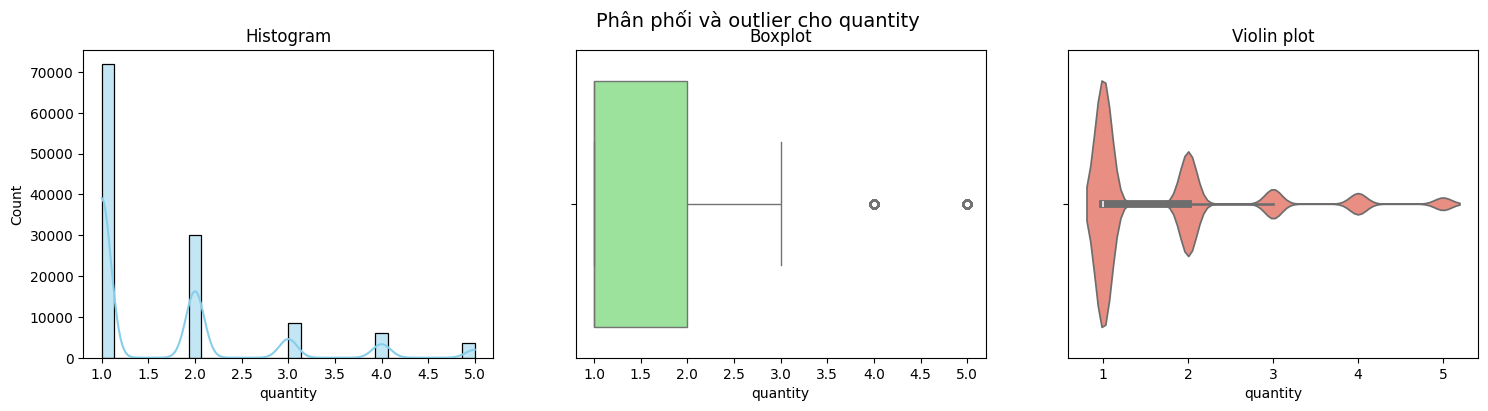

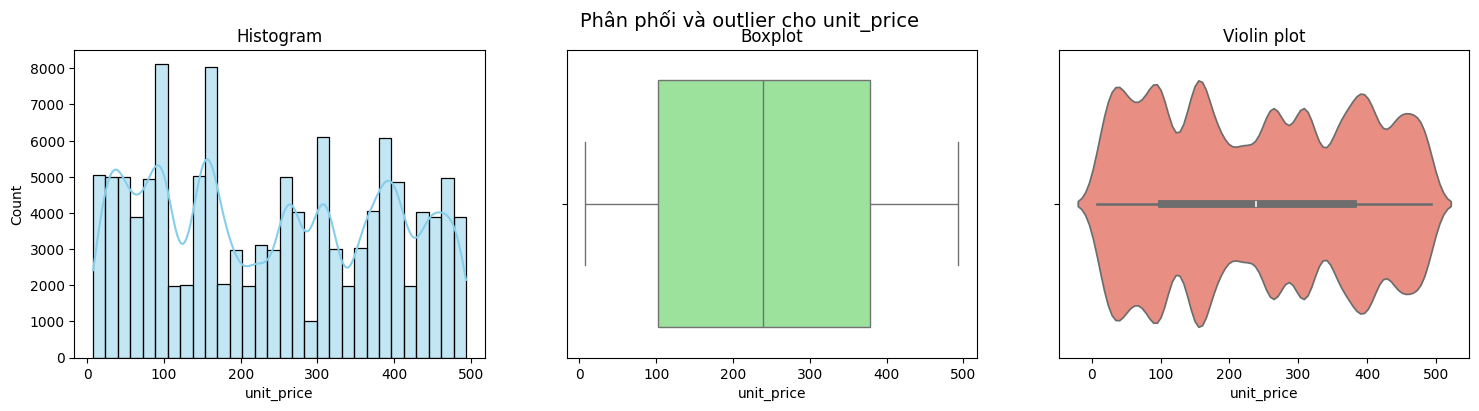

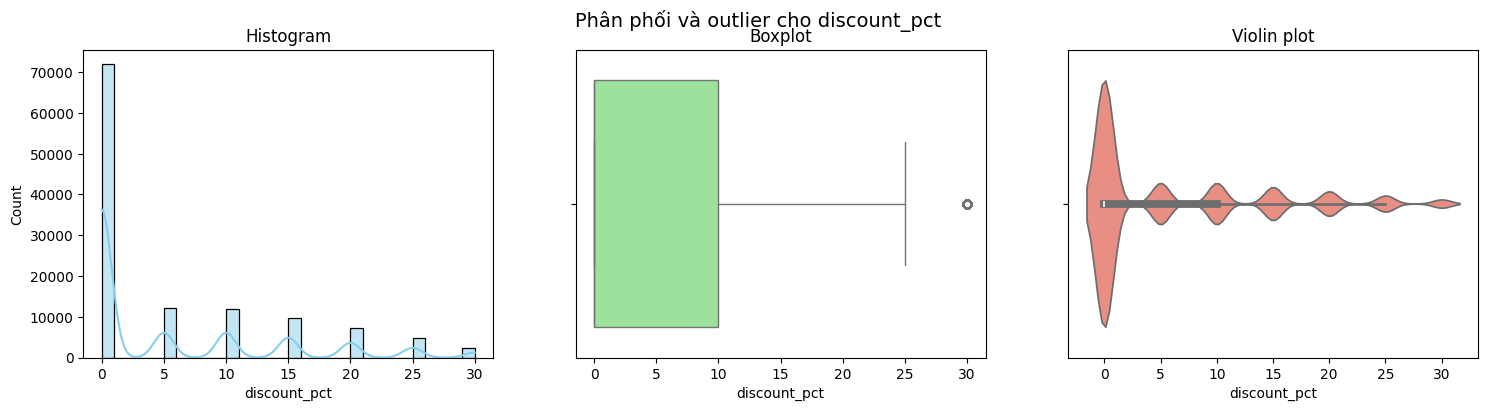

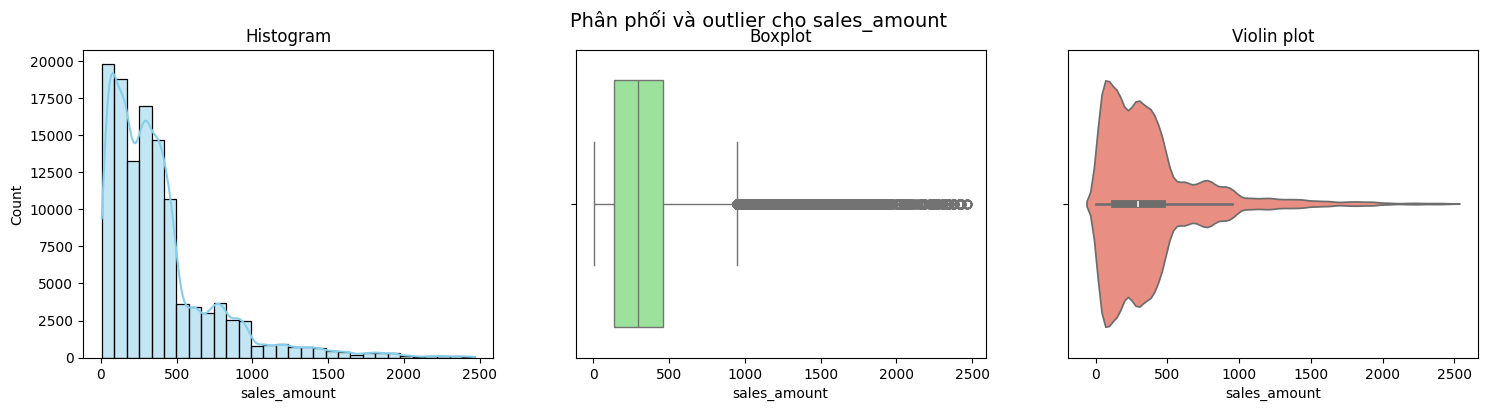

In [61]:
numeric_cols = ["quantity", "unit_price", "discount_pct", "sales_amount"]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Phân phối và outlier cho {col}", fontsize=14)

    # 1. Histogram
    sns.histplot(df_clean[col], bins=30, kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title("Histogram")

    # 2. Boxplot (dễ thấy outlier)
    sns.boxplot(x=df_clean[col], ax=axes[1], color="lightgreen")
    axes[1].set_title("Boxplot")

    # 3. Violin plot (phân phối + mật độ)
    sns.violinplot(x=df_clean[col], ax=axes[2], color="salmon")
    axes[2].set_title("Violin plot")

    plt.show()


**Insight**

- `quantity`: phân phối tập trung mạnh ở mức `1` và `2`, sau đó giảm dần ở `3`, `4`, `5`. Boxplot xuất hiện nhiều outlier phía phải nên `4` và `5` là outlier thống kê.    

- `unit_price`: phân phối trải khá rộng nhưng không vượt ngưỡng IQR, nên **không có outlier**

- `discount_pct`: dữ liệu rời rạc theo các mức `0, 5, 10, 15, 20, 25, 30`, ngưỡng trên là `25`, nên toàn bộ giá trị `30` bị xem là outlier thống kê. 

- `sales_amount`: phân phối lệch phải mạnh. Tất cả outlier IQR của cột này đều nằm ở **phía trên ngưỡng**, phản ánh các giao dịch có giá trị cao do giá bán cao, số lượng lớn hoặc cả hai. 

In [62]:
target_cols = ['quantity', 'discount_pct', 'sales_amount']
context_cols = ['sales_channel', 'customer_segment']

def iqr_bounds(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

for col in target_cols:
    # kiểm tra global outlier
    lower_g, upper_g = iqr_bounds(df_clean[col])
    df_clean[f'{col}_global'] = ((df_clean[col] < lower_g) | (df_clean[col] > upper_g))

    # kiểm tra context outlier
    def detect_context(group):
        lower_c, upper_c  = iqr_bounds(group[col])
        group[f'{col}_context'] = ((group[col] < lower_c) | (group[col] > upper_c))

        return group
    
    df_clean = df_clean.groupby(context_cols, group_keys=False).apply(detect_context)

    def final_label(row):
        if row[f'{col}_global']:
            return 'global'

        elif row[f'{col}_context']:
            return 'context'

        return 'normal'
        

    df_clean[f'{col}_outlier_type'] = df_clean.apply(final_label, axis=1)

In [63]:
def show_outlier_info(df_clean, col, type_col='outlier_type', top_n=20):
    # lấy ra các dòng có outlier
    outlier_df_clean = df_clean[df_clean[type_col] != 'normal'].copy()

    print("=" * 80)
    print(f"{col}")

    # describe
    print("\n[DESCRIBE]")
    print(outlier_df_clean[col].describe())

    # value_counts
    print("\n[VALUE COUNTS]")
    print(outlier_df_clean[col].round(2).value_counts().head(top_n))

    # số lượng từng loại outlier
    print("\n[OUTLIER COUNTS]")
    print(outlier_df_clean[type_col].value_counts())

show_outlier_info(df_clean, 'quantity', 'quantity_outlier_type')
show_outlier_info(df_clean, 'discount_pct', 'discount_pct_outlier_type')
show_outlier_info(df_clean, 'sales_amount', 'sales_amount_outlier_type')

quantity

[DESCRIBE]
count    9702.000000
mean        4.370233
std         0.482892
min         4.000000
25%         4.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: quantity, dtype: float64

[VALUE COUNTS]
quantity
4    6110
5    3592
Name: count, dtype: int64

[OUTLIER COUNTS]
quantity_outlier_type
global    9702
Name: count, dtype: int64
discount_pct

[DESCRIBE]
count    2429.0
mean       30.0
std         0.0
min        30.0
25%        30.0
50%        30.0
75%        30.0
max        30.0
Name: discount_pct, dtype: float64

[VALUE COUNTS]
discount_pct
30.0    2429
Name: count, dtype: int64

[OUTLIER COUNTS]
discount_pct_outlier_type
global    2429
Name: count, dtype: int64
sales_amount

[DESCRIBE]
count    8398.000000
mean     1362.444594
std       355.523322
min       927.910000
25%      1074.180000
50%      1280.080000
75%      1556.060000
max      2467.550000
Name: sales_amount, dtype: float64

[VALUE COUNTS]
sales_amount
987.02     153
969.88     149


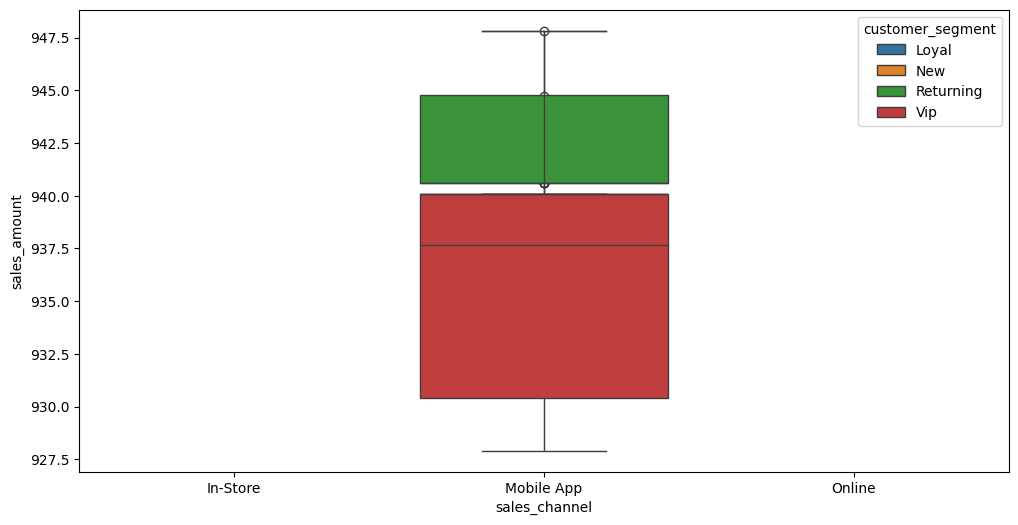

In [64]:
# chỉ lấy context outlier
context_df = df_clean[df_clean['sales_amount_outlier_type'] == 'context']

plt.figure(figsize=(12,6))
sns.boxplot(
    data=context_df,
    x='sales_channel',
    y='sales_amount',
    hue='customer_segment'
)
plt.show()

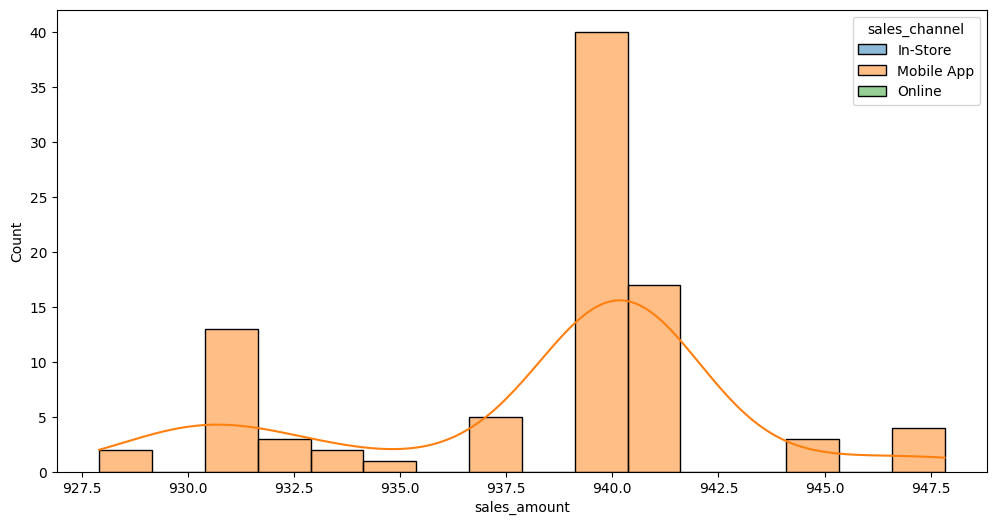

In [65]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=context_df,
    x='sales_amount',
    hue='sales_channel',
    kde=True
)
plt.show()

**Insight**

1. Quantity:
Tất cả outlier của `quantity` đều thuộc loại `global`, ở mức 4 và 5
- giá trị 4 xuất hiện nhiều nhất,
- phân phối khá tập trung trung và có độ lệch chuẩn thấp, các giá trị không quá phân tán,
- không có dấu hiệu rõ ràng theo từng nhóm context,
- các giá trị này có thể phản ánh các đơn hàng mua số lượng lớn hơn mức phổ biến chung của dataset.

2. Discount: 
Toàn bộ outlier của `discount_pct` đều là `global`, và tất cả đều có cùng giá trị 30%.
- mức giảm giá 30% cao hơn đáng kể so với phần lớn dữ liệu còn lại,
- không có khác biệt theo  từng nhóm context.

3. Sales amount:
Số lượng outlier chủ yếu là `global` và `context` chỉ chiếm số lượng nhỏ.
- các giá trị outlier trải rộng từ khoảng 927 đến 2467,
- outlier lệch phải với nhiều đơn hàng giá trị cao.

- Sau khi kiểm tra 90 bản ghi `context` bằng boxplot và histogram:
    - các `context` không tạo ra pattern bất thường rõ rệt,
    - phân phối của chúng khá đều và tập trung,
    - mức độ lệch khỏi group không quá mạnh, nên các outlier này không phải là outlier `context`

**Action**
- Giữ lại các bản ghi, và gắn flag.

In [66]:
# tạo flag cho các bản ghi outlier
for col in target_cols:

    df[f'{col}_outlier_type'] = df_clean[f'{col}_outlier_type']
    df[f'{col}_outlier_flag'] = df[f'{col}_outlier_type'] != 'normal'



### Kiểm tra lại trước khi load data đã làm sạch

In [67]:
# kiểm tra missing và dup 

print("Missing cells:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing cells: 484
Duplicate rows: 0


In [68]:
# kiểm tra giá trị âm

# loại các dòng đã bị flag trước khi kiểm tra
flag_cols = [
    "discount_pct_mismatch",
    "quantity_neg",
    "sales_amount_neg",
    "sales_amount_mismatch"
]

df_check = df.loc[~df[flag_cols].any(axis=1)].copy()

print("\nQuantity <= 0:", (df_check["quantity"] <= 0).sum())
print("Unit price <= 0:", (df_check["unit_price"] <= 0).sum())
print("Discount ngoài khoảng 0–100:",
      ((df_check["discount_pct"] < 0) |
       (df_check["discount_pct"] > 100)).sum())
print("Sales amount < 0:",
      (df_check["sales_amount"] < 0).sum())


Quantity <= 0: 0
Unit price <= 0: 0
Discount ngoài khoảng 0–100: 0
Sales amount < 0: 0


In [69]:
# kiểm tra tính nhất quán có lỗi logic nghiệp vụ không
expected_sales = (
    df_check["quantity"] * df_check["unit_price"] * (1 - df_check["discount_pct"] / 100)
)
sales_diff = (df_check["sales_amount"] - expected_sales).abs()

print("Sales mismatch > 0.01:", (sales_diff > 0.01).sum())


Sales mismatch > 0.01: 0


In [70]:
# kiểm tra giá trị duy nhất của các cột phân loại
for col in ['payment_method', 'category', 'sales_channel']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")


--- payment_method ---
payment_method
Credit Card    24387
Cash           24001
Paypal         23964
Debit Card     23867
Gift Card      23781
Name: count, dtype: int64


--- category ---
category
Sports         15218
Clothing       15156
Beauty         15073
Groceries      15034
Toys           15022
Electronics    15008
Home           14933
Books          14556
Name: count, dtype: int64


--- sales_channel ---
sales_channel
Online        43787
In-Store      41767
Mobile App    34446
Name: count, dtype: int64




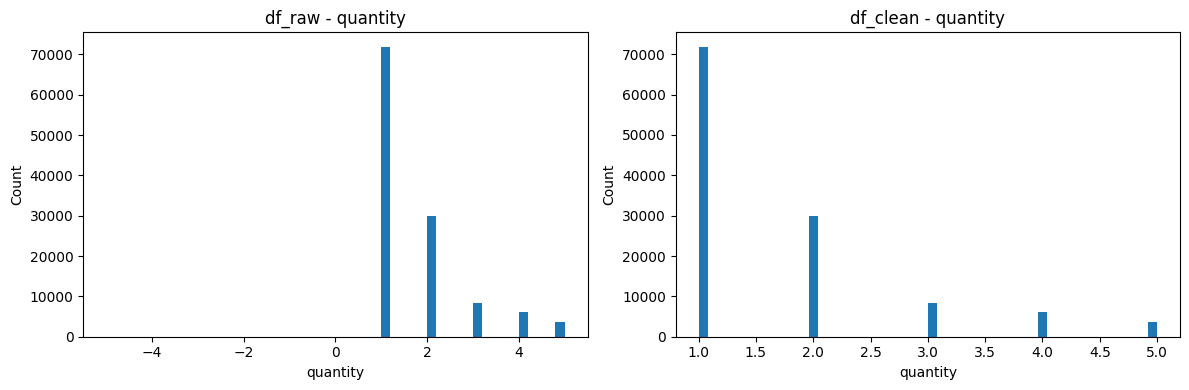

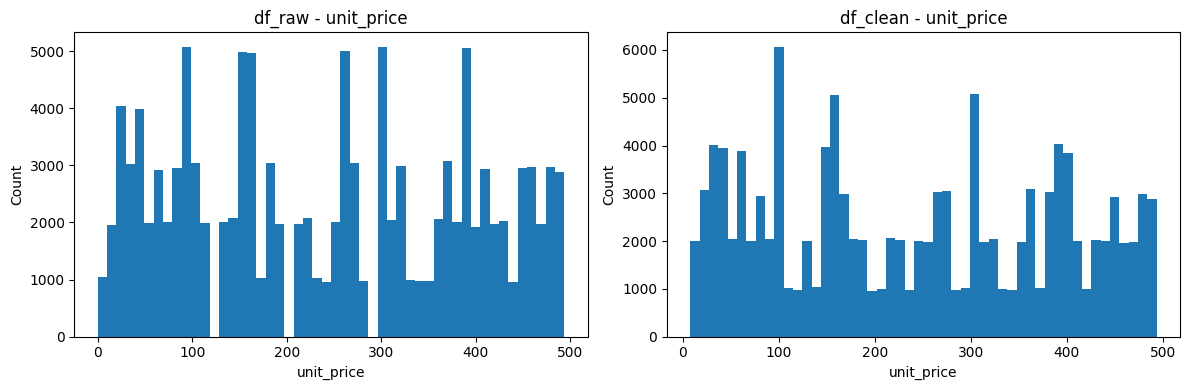

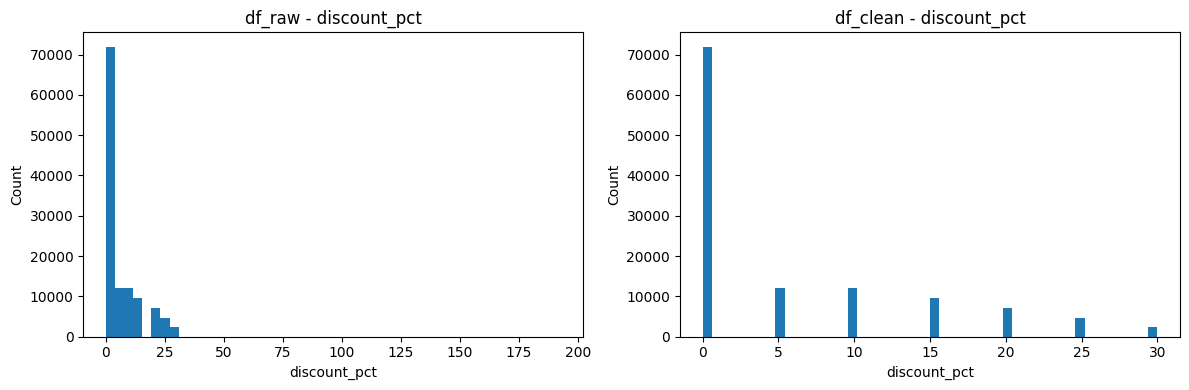

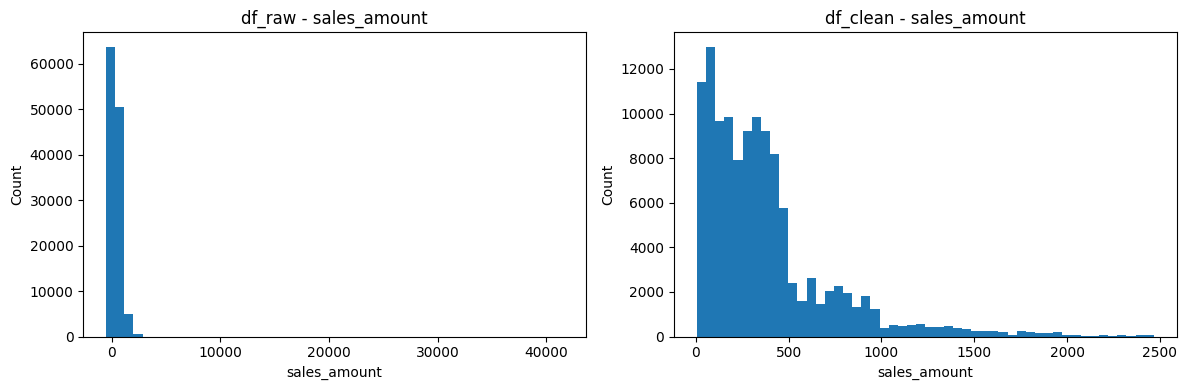

In [71]:
num_cols = ["quantity", "unit_price", "discount_pct", "sales_amount"]

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_raw[col].dropna(), bins=50)
    axes[0].set_title(f"df_raw - {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    axes[1].hist(df_check[col].dropna(), bins=50)
    axes[1].set_title(f"df_clean - {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

In [72]:
# phân phố trước và sau cleaning 

summary_before = df_raw[["quantity", "unit_price", "discount_pct", "sales_amount"]].describe().T
summary_after = df_check[["quantity", "unit_price", "discount_pct", "sales_amount"]].describe().T

print("-- Trước cleaning -- ")
display(summary_before)

print("-- Sau cleaning --")
display(summary_after)

-- Trước cleaning -- 


,count,mean,std,min,25%,50%,75%,max
quantity,120000.0,1.662625,1.014755,-5.0,1.00,1.00,2.0,5.000000
unit_price,120000.0,240.611484,146.460499,0.0,102.01,238.75,379.0,493.510000
discount_pct,120000.0,5.507762,8.290149,0.0,0.00,0.00,10.0,192.620148
sales_amount,119818.0,378.814476,391.034255,-531.1,136.86,295.98,461.5,41520.000000


-- Sau cleaning --


,count,mean,std,min,25%,50%,75%,max
quantity,119960.0,1.662971,1.014298,1.00,1.00,1.00,2.0,5.00
unit_price,119960.0,240.632015,146.454920,7.73,102.01,238.75,379.0,493.51
discount_pct,119960.0,5.495582,8.192700,0.00,0.00,0.00,10.0,30.00
sales_amount,119960.0,378.017864,356.926607,5.41,136.86,295.98,461.5,2467.55


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   transaction_id             120000 non-null  category      
 1   transaction_date           120000 non-null  datetime64[ns]
 2   customer_id                120000 non-null  category      
 3   customer_gender            120000 non-null  category      
 4   customer_age_group         120000 non-null  category      
 5   customer_segment           120000 non-null  category      
 6   product_id                 120000 non-null  category      
 7   product_name               120000 non-null  category      
 8   category                   120000 non-null  category      
 9   brand                      120000 non-null  category      
 10  quantity                   120000 non-null  int64         
 11  unit_price                 120000 non-null  float64 

**Kết luận**
- Không có bản ghi nào missing, duplicate. 
- Không còn giá trị âm/vô lý, logic nghiệp vụ chính xác.
- Phân phối trước và sau của các cột numeric không có chênh lệch đáng kể.
- Kiểu dữ liệu chính xác ở từng cột.

### Load dữ liệu đã làm sạch

In [74]:
df.to_csv('D:/2022-2026/Project-Data Analysis/DA_Channel/data/processed/retail_dataset_cleaned.csv', index=False)

In [75]:
# loại bỏ các bản ghi có flag = True ở 4 cột lỗi
df_clean = df[
    ~(df["discount_pct_mismatch"]) &
    ~(df["quantity_neg"]) &
    ~(df["sales_amount_neg"]) &
    ~(df["sales_amount_mismatch"])
]

# lưu file sạch để dùng cho Power BI
df_clean.to_csv(
    'D:/2022-2026/Project-Data Analysis/DA_Channel/data/processed/retail_dataset_powerbi.csv',
    index=False
)

print("Rows after cleaning:", len(df_clean))

Rows after cleaning: 119960


[EDA.ipynb](notebooks/EDA.ipynb) [retail_dataset_cleaned.csv](data/processed/retail_dataset_cleaned.csv) 
xem 2 file này và viết các insight từ các biểu đồ vào markdown trong file eda này, phía dưới từng output của các cell code, và phù hợp với mục tiêu bài toán:
Phân tích hành vi mua hàng của khách hàng trên nhiều kênh bán hàng để so sánh hiệu quả giữa online và offline. Dự án nhằm xác định kênh bán hàng nào hiệu quả hơn và kênh nào phù hợp với từng phân khúc khách hàng.

yêu cầu:
1. dữ liệu đang nói gì, xu hướng đang xảy ra, nhóm nào khác biệt, thời điểm nổi bật.... nếu có
2. không bịa địa, phải chính xác và rõ ràng, logic, không lặp lại từ ngữ, không sử dụng từ ngữ học thuật. 

sau đó ở cuối tạo 1 markdown viết actions, yêu cầu:
1. không phải là gợi ý chung chung, xuất phát từ insight. 
2. phải phản ánh cách phản ứng với xu hướng tìm được từ phân tích, không được đưa đề xuất không được dữ liệu hỗ trợ 
3. actions phải khả thi, ko mơ hồ, thực hiện được , phù hợp với quy trình thực  tế.
4. actions phải gắn với mục tiêu kinh doanh, vận hành, cụ thể để hiểu phải làm gì.
5. đánh giá mức độ ảnh hưởng, ưu tiên.